# Trends in Mental Health in Toronto - 2019

<p> This is a notebook to show the different trends in mental health. The dataset I explored had information for the years 2019-2022 ish.</p>

The data used in this post is sourced from Population Health Status Indicators by [Open Data Toronto](https://www.ontariohealthprofiles.ca/torontohealthstatus/mental-health-and-substance-use.php).

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [20]:
data = pd.read_csv("data.csv")

## Checking out the columns and an overview of what the dataframe looks like

In [21]:
print(data.columns)

Index(['Topic Area', 'Indicator Name', 'Measure', 'Data Year', 'Stratifier',
       'Subgroup', 'Unit', 'Value', 'LL', 'UL', 'Flag', 'Comparison'],
      dtype='object')


In [22]:
print(data.head())

                        Topic Area  \
0  Mental_Health_and_Substance_Use   
1  Mental_Health_and_Substance_Use   
2  Mental_Health_and_Substance_Use   
3  Mental_Health_and_Substance_Use   
4  Mental_Health_and_Substance_Use   

                                      Indicator Name  \
0  Three to Six Standard Drinks in the Past Seven...   
1  Three to Six Standard Drinks in the Past Seven...   
2  Three to Six Standard Drinks in the Past Seven...   
3  Three to Six Standard Drinks in the Past Seven...   
4  Three to Six Standard Drinks in the Past Seven...   

                                             Measure  Data Year  \
0  Percent of adults (19 years and older) who rep...  2019-2020   
1  Percent of adults (19 years and older) who rep...  2019-2020   
2  Percent of adults (19 years and older) who rep...  2019-2020   
3  Percent of adults (19 years and older) who rep...  2019-2020   
4  Percent of adults (19 years and older) who rep...  2019-2020   

              Stratifier       

A general overview, I am considering 2019-2020 data as the data for 2019.

## Data cleaning

In [23]:
df = data.copy() #making a copy of data

#converting 2019-2020 to 2019
def convert_year_range(x):
    if isinstance(x, str) and "-" in x:
        start = x.split("-")[0]
        return int(start)
    else:
        return pd.to_numeric(x, errors="coerce")

df["Data Year"] = df["Data Year"].apply(convert_year_range)
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df.dropna(subset=["Data Year", "Value"])

In [24]:
print(df["Stratifier"].unique())

['Overall' 'Region_within_Ontario' 'Time' 'Age' 'Gender'
 'Immigrant_Status' 'Ethno_Racial_Identity' 'Income_Quintile'
 'Highest_Education_Level' 'Sub_Toronto_Geography_Clusters'
 'Sexual_Orientation' 'Sex' 'Females_by_Age' 'Males_by_Age'
 'Neighbourhood_Number' 'Maternal_Age' 'Parity']


We checked the stratifier to see what word we are using for total 

In [25]:
df = df[df["Stratifier"] == "Overall"]

In [26]:
print(df["Indicator Name"].unique())

['Three to Six Standard Drinks in the Past Seven Days (Moderate Risk)'
 'Alcohol Use in the Past Year' 'Cannabis Use in the Past Year'
 'Consulted a Professional to Discuss Mental or Emotional Health' 'Coping'
 'Exceeding 2011 Low-Risk Drinking Guidelines' 'Happiness'
 'Heavy Drinking Episodes' 'Life Satisfaction' 'Life Stress'
 'Lifetime Abstinence' 'No Drink in the Past Seven Days'
 'One or Two Standard Drinks in the Past Seven Days (Low Risk)'
 'Self-Rated Mental Health' 'Self-Reported Mood Disorder'
 'Sense of Belonging to Local Community' 'Social Support'
 'Three or More Standard Drinks in the Past Seven Days (Exceeds Low Risk)'
 'Work Stress' 'Intentional Self-Harm ED Visits'
 'Intentional Self-Harm Hospitalizations' 'Anxiety During Pregnancy'
 'Depression During Pregnancy'
 'Seven or More Standard Drinks in the Past Seven Days (High Risk)'
 'Cannabis Use Frequency in the Past Year'
 'Mental Health Concern During Pregnancy'
 'Cannabis related harms ED visits (18 years and older)'

My goal is just to check the general mental health.

In [27]:
selected_indicators = [
    "Self-Rated Mental Health",
    "Life Stress",
    "Happiness",
    "Life Satisfaction",
    "Sense of Belonging to Local Community",
    "Social Support",
    "Consulted a Professional to Discuss Mental or Emotional Health",
    "Self-Reported Mood Disorder"
]

df = df[df["Indicator Name"].isin(selected_indicators)]

In [28]:
print(df["Indicator Name"].unique())

['Consulted a Professional to Discuss Mental or Emotional Health'
 'Happiness' 'Life Satisfaction' 'Life Stress' 'Self-Rated Mental Health'
 'Self-Reported Mood Disorder' 'Sense of Belonging to Local Community'
 'Social Support']


## Lets divide these to happiness and stress

In [29]:
group1 = [
    "Happiness",
    "Life Satisfaction",
    "Sense of Belonging to Local Community",
    "Social Support"
]

group2 = [
    "Life Stress",
    "Self-Reported Mood Disorder",
    "Consulted a Professional to Discuss Mental or Emotional Health",
    "Self-Rated Mental Health"
]

In [30]:
df1 = df[df["Indicator Name"].isin(group1)]
df2 = df[df["Indicator Name"].isin(group2)]

df1 = wellbeing indicators/happiness , 
df2 = mental distress indicators/stress

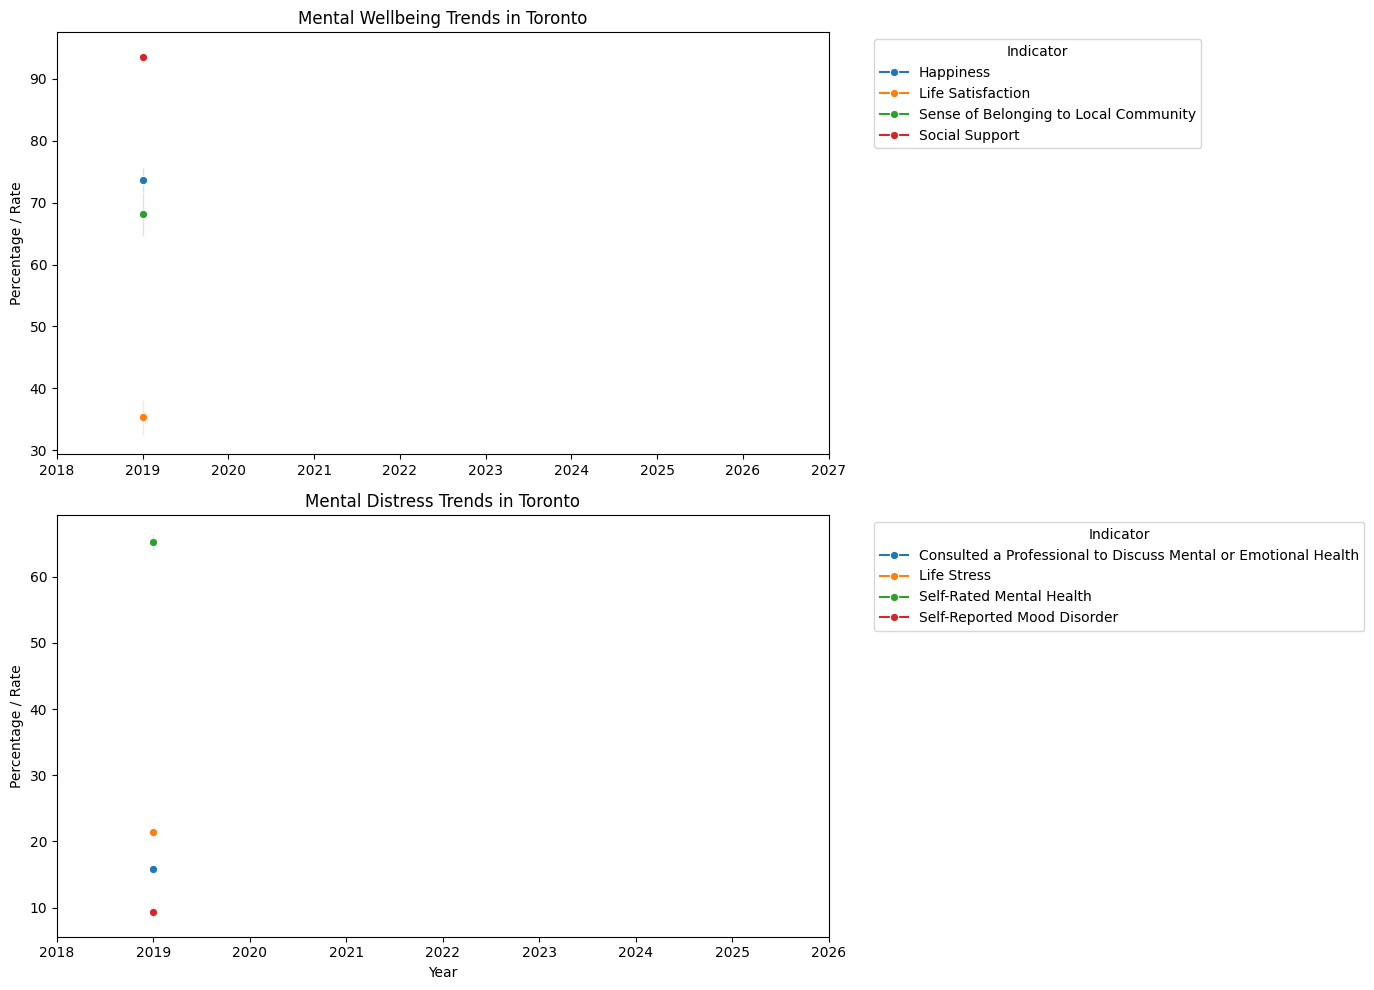

In [31]:

fig, axes = plt.subplots(2, 1, figsize=(14,10))

# Graph 1: Wellbeing
sns.lineplot(
    data=df1,
    x="Data Year",
    y="Value",
    hue="Indicator Name",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Mental Wellbeing Trends in Toronto")
axes[0].set_xlabel("")
axes[0].set_ylabel("Percentage / Rate")
axes[0].legend(title="Indicator", bbox_to_anchor=(1.05, 1), loc='upper left')

axes[0].set_xlim(2018, 2027)

# Graph 2: Distress
sns.lineplot(
    data=df2,
    x="Data Year",
    y="Value",
    hue="Indicator Name",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Mental Distress Trends in Toronto")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Percentage / Rate")
axes[1].legend(title="Indicator", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
axes[1].set_xlim(2018, 2026)

plt.show()